In [3]:
import pandas as pd

base = "/home/voare/Documents/Synheart/Kinematics/Dataset/UCI HAR Dataset"

# column names for the features
features = pd.read_csv(base + "/features.txt", sep=r"\s+", header=None)[1].tolist()

# train data: rows = time windows, columns = features
X = pd.read_csv(base + "/train/X_train.txt", sep=r"\s+", header=None)
X.columns = features

print(X.shape)
X.head()

(7352, 561)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


In [4]:
# the activity for each row (a number 1-6)
y = pd.read_csv(base + "/train/y_train.txt", header=None)[0]

# what those numbers mean
names = pd.read_csv(base + "/activity_labels.txt", sep=r"\s+", header=None, index_col=0)[1]
print(names.to_dict())

# how many rows per activity
y.map(names).value_counts()

{1: 'WALKING', 2: 'WALKING_UPSTAIRS', 3: 'WALKING_DOWNSTAIRS', 4: 'SITTING', 5: 'STANDING', 6: 'LAYING'}


0
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

In [5]:
# which person recorded each row (1-30)
subject = pd.read_csv(base + "/train/subject_train.txt", header=None)[0]
print("people in train:", sorted(subject.unique()))

people in train: [np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]


In [6]:
# the feature values are already scaled between -1 and 1
X.iloc[:, :6].describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,0.274488,-0.017695,-0.109141,-0.605438,-0.510938,-0.604754
std,0.070261,0.040811,0.056635,0.448734,0.502645,0.418687
min,-1.000000,-1.000000,-1.000000,-1.000000,-0.999873,-1.000000
25%,0.262975,-0.024863,-0.120993,-0.992754,-0.978129,-0.980233
50%,0.277193,-0.017219,-0.108676,-0.946196,-0.851897,-0.859365
75%,0.288461,-0.010783,-0.097794,-0.242813,-0.034231,-0.262415
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000


/tmp/ipykernel_98458/349437512.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X["activity"] = y.map(names)


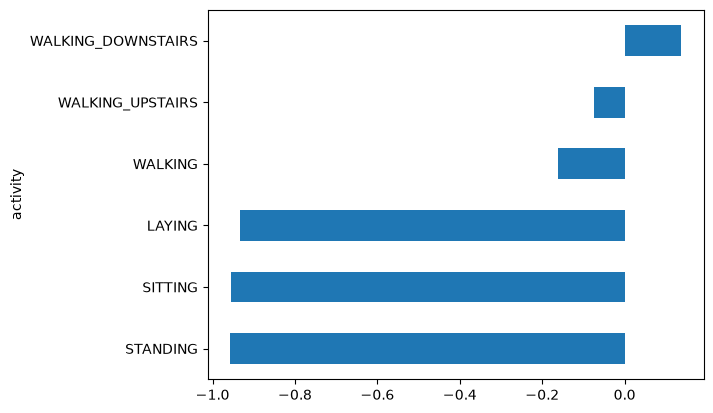

In [7]:
import matplotlib.pyplot as plt

# average body-acceleration magnitude per activity (still vs moving)
X["activity"] = y.map(names)
X.groupby("activity")["tBodyAccMag-mean()"].mean().sort_values().plot(kind="barh")
plt.show()

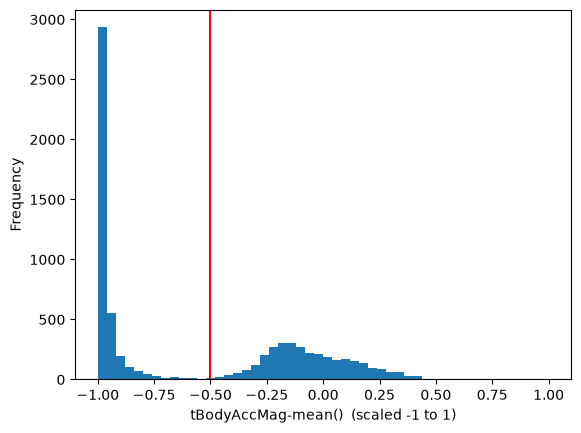

In [8]:
import matplotlib.pyplot as plt

# how the values of one feature spread across -1 to 1
X["tBodyAccMag-mean()"].plot(kind="hist", bins=50)
plt.axvline(-0.5, color="red")          # the still/moving line we found
plt.xlabel("tBodyAccMag-mean()  (scaled -1 to 1)")
plt.show()


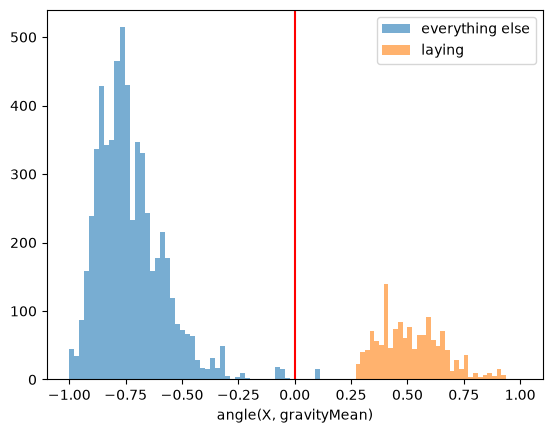

In [9]:
# ---- validating mentor claim #1 ----
# claim: angle(X,gravityMean) > 0  =>  LAYING  (he says it catches ALL laying)
# why: standing/sitting the phone is upright (X along gravity, angle < 0);
#      laying the phone is flat (X sideways to gravity, angle > 0)
import matplotlib.pyplot as plt

a = X["angle(X,gravityMean)"]
laying = X["activity"] == "LAYING"

plt.hist(a[~laying], bins=50, alpha=0.6, label="everything else")
plt.hist(a[laying],  bins=50, alpha=0.6, label="laying")
plt.axvline(0, color="red")
plt.xlabel("angle(X, gravityMean)")
plt.legend()
plt.show()

# result: catches 1406 of 1407 laying, but 15 sitting leak in  ->  ~99%, not "ALL"


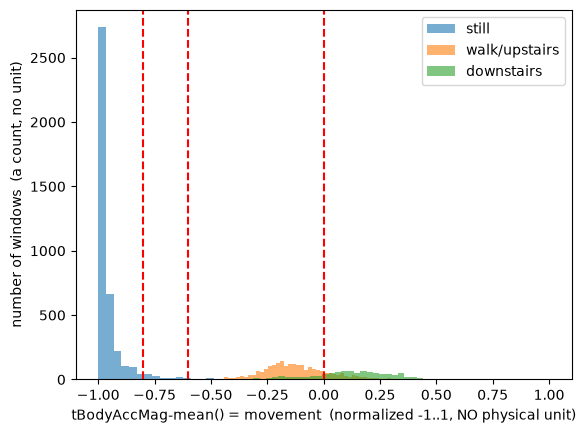

In [10]:
# ---- validating mentor claim #2 ----
# claim: tAccMean (= tBodyAccMag-mean) < -0.8 => still, > -0.6 => moving, > 0 => downstairs
import matplotlib.pyplot as plt

m = X["tBodyAccMag-mean()"]
group = X["activity"].map({
    "SITTING": "still", "STANDING": "still", "LAYING": "still",
    "WALKING": "walk/upstairs", "WALKING_UPSTAIRS": "walk/upstairs",
    "WALKING_DOWNSTAIRS": "downstairs"})

for g, c in [("still", "tab:blue"), ("walk/upstairs", "tab:orange"), ("downstairs", "tab:green")]:
    plt.hist(m[group == g], bins=50, alpha=0.6, label=g, color=c)

for x in [-0.8, -0.6, 0.0]:                 # his three thresholds (red dashed)
    plt.axvline(x, color="red", linestyle="--")

plt.xlabel("tBodyAccMag-mean() = movement  (normalized -1..1, NO physical unit)")  # x = feature value
plt.ylabel("number of windows  (a count, no unit)")                        # y = how many windows
plt.legend()
plt.show()

# verdict: <-0.8 => still 100%  |  >-0.6 => moving 97.7%  |  >0 => downstairs only 62.6% (weak)


In [11]:
# ---- locking in mentor claim #2's "we can classify 75%" ----
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# load the test people (train X already loaded above)
Xte = pd.read_csv(base + "/test/X_test.txt", sep=r"\s+", header=None); Xte.columns = features
yte = pd.read_csv(base + "/test/y_test.txt", header=None)[0].map(names)
ytr = X["activity"]

def simple_acc(cols):
    clf = DecisionTreeClassifier(max_depth=6, random_state=0).fit(X[cols].to_numpy(), ytr)
    return round(accuracy_score(yte, clf.predict(Xte[cols].to_numpy())) * 100, 1)

print("movement only           :", simple_acc(["tBodyAccMag-mean()"]), "%")
print("movement + laying-angle :", simple_acc(["tBodyAccMag-mean()", "angle(X,gravityMean)"]), "%")
print("(mentor full 561 SVM    : 97.9 %)")

# crosstab: rows = true activity, cols = predicted using movement only
clf = DecisionTreeClassifier(max_depth=6, random_state=0).fit(X[["tBodyAccMag-mean()"]].to_numpy(), ytr)
print()
print(pd.crosstab(yte, clf.predict(Xte[["tBodyAccMag-mean()"]].to_numpy())))

# verdict: his "75%" is too rosy. movement alone = ~43% (great at still-vs-moving,
# but random within still, and upstairs looks like walking)


movement only           : 42.9 %
movement + laying-angle : 68.6 %
(mentor full 561 SVM    : 97.9 %)

col_0               LAYING  SITTING  STANDING  WALKING  WALKING_DOWNSTAIRS  \
0                                                                            
LAYING                 150      162       220        4                   1   
SITTING                140      148       199        4                   0   
STANDING               150       92       289        1                   0   
WALKING                  0        0         0      438                  23   
WALKING_DOWNSTAIRS       0        0         0      167                 176   
WALKING_UPSTAIRS         0        0         0      381                  26   

col_0               WALKING_UPSTAIRS  
0                                     
LAYING                             0  
SITTING                            0  
STANDING                           0  
WALKING                           35  
WALKING_DOWNSTAIRS                77  
W

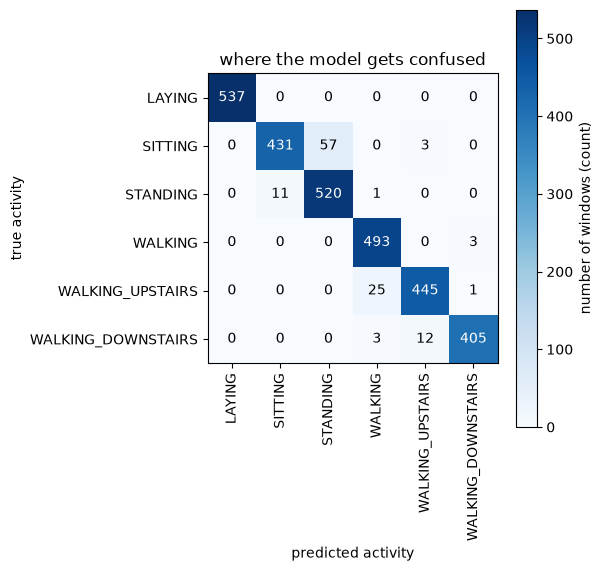

In [12]:
# ---- validating mentor claim #3: "sit vs stand is the ONLY inseparable pair" ----
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# load train + test fresh as plain numbers (avoids the duplicate-name columns)
Xtr = pd.read_csv(base + "/train/X_train.txt", sep=r"\s+", header=None).to_numpy()
Xte = pd.read_csv(base + "/test/X_test.txt",  sep=r"\s+", header=None).to_numpy()
ytr = pd.read_csv(base + "/train/y_train.txt", header=None)[0].map(names)
yte = pd.read_csv(base + "/test/y_test.txt",  header=None)[0].map(names)

labels = ["LAYING","SITTING","STANDING","WALKING","WALKING_UPSTAIRS","WALKING_DOWNSTAIRS"]
clf = LogisticRegression(max_iter=2000).fit(Xtr, ytr)
cm = confusion_matrix(yte, clf.predict(Xte), labels=labels)

plt.figure(figsize=(6,6))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(6), labels, rotation=90)
plt.yticks(range(6), labels)
plt.xlabel("predicted activity")          # x-axis: what the model guessed
plt.ylabel("true activity")               # y-axis: the real activity
for i in range(6):
    for j in range(6):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(label="number of windows (count)")
plt.title("where the model gets confused")
plt.tight_layout(); plt.show()

# verdict: SIT<->STAND = biggest (68 errors). but UP->WALKING (25) and DWN->UP (12)
# are a 2nd fuzzy zone -> his "ONLY sit/stand" is overstated. laying = perfect (0).


In [13]:
# ---- mentor claims #4 (10% faster downstairs) and #5 (labels equally distributed) ----
acts = pd.read_csv(base + "/train/y_train.txt", header=None)[0].map(names)
subj = pd.read_csv(base + "/train/subject_train.txt", header=None)[0]
c = acts.value_counts()

# claim #4: more upstairs windows => downstairs took less time => faster
up, down = c["WALKING_UPSTAIRS"], c["WALKING_DOWNSTAIRS"]
print(f"CLAIM #4: upstairs {up} vs downstairs {down}  ->  downstairs ~{(up/down-1)*100:.0f}% faster")
t = pd.crosstab(subj, acts)
print("  subjects with more upstairs than downstairs:",
      (t["WALKING_UPSTAIRS"] > t["WALKING_DOWNSTAIRS"]).sum(), "/", t.shape[0])

# claim #5: how balanced are the 6 classes?
print("\nCLAIM #5: each class as % of data (equal would be 16.7%):")
print((c / len(acts) * 100).round(1).to_string())
print("  biggest/smallest ratio:", round(c.max() / c.min(), 2))

# verdict #4: ~9% faster (he said ~10%) + 19/21 subjects  ->  VALID
# verdict #5: all classes 13-19%  ->  VALID (quite balanced, mild skew to still)


CLAIM #4: upstairs 1073 vs downstairs 986  ->  downstairs ~9% faster
  subjects with more upstairs than downstairs: 19 / 21

CLAIM #5: each class as % of data (equal would be 16.7%):
0
LAYING                19.1
STANDING              18.7
SITTING               17.5
WALKING               16.7
WALKING_UPSTAIRS      14.6
WALKING_DOWNSTAIRS    13.4
  biggest/smallest ratio: 1.43


In [14]:
# ---- mentor claim #6: collapsing the 3 walks -> "MOVING" (his design choice) ----
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

Xtr = pd.read_csv(base + "/train/X_train.txt", sep=r"\s+", header=None).to_numpy()
Xte = pd.read_csv(base + "/test/X_test.txt",  sep=r"\s+", header=None).to_numpy()
ytr = pd.read_csv(base + "/train/y_train.txt", header=None)[0].map(names)
yte = pd.read_csv(base + "/test/y_test.txt",  header=None)[0].map(names)

def merge(y):                      # the 3 walks become one "MOVING" class
    return y.replace(["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS"], "MOVING")

acc6 = accuracy_score(yte, LogisticRegression(max_iter=2000).fit(Xtr, ytr).predict(Xte))
acc4 = accuracy_score(merge(yte), LogisticRegression(max_iter=2000).fit(Xtr, merge(ytr)).predict(Xte))
print(f"6 classes (keep walk types) : {acc6*100:.1f}%")
print(f"4 classes (walks -> MOVING) : {acc4*100:.1f}%")
# verdict: merging deletes the walk-type confusion -> +1.7% and fits the "detect motion" goal -> SMART


6 classes (keep walk types) : 96.1%
4 classes (walks -> MOVING) : 97.8%
